# CyteOnto Analysis

This notebook takes outputs from CyteOnto CLI and runs analyses to quantify the agreement between STATE and CyteType labels

In [45]:
import math
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Mean similarity by STATE annotation

In [58]:
similarities = pd.read_csv(Path("..") / "output" / "cyteonto" / "runs" / "run-f4150be4-698a-4866-a16e-1373b716695b.csv")
similarities.head()

,run_id,algorithm,pair_index,author_label,algorithm_label,author_ontology_id,author_embedding_similarity,algorithm_ontology_id,algorithm_embedding_similarity,cytescore_similarity,similarity_method
0,run-f4150be4-698a-4866-a16e-1373b716695b,algo1,0,macrophage,"Alveolar macrophage, inflammatory lipid-associ...",CL:0000235,0.8967,CL:0000583,0.8450,0.5048,cytescore
1,run-f4150be4-698a-4866-a16e-1373b716695b,algo1,1,macrophage,"Alveolar macrophage, SPP1+ inflammatory",CL:0000235,0.8967,CL:0000583,0.8203,0.5048,cytescore
2,run-f4150be4-698a-4866-a16e-1373b716695b,algo1,2,lung multiciliated epithelial cell,Multiciliated airway epithelial cells,CL:1000271,0.9430,CL:1000271,0.9161,1.0000,cytescore
3,run-f4150be4-698a-4866-a16e-1373b716695b,algo1,3,macrophage,Recruited inflammatory macrophage,CL:0000235,0.8966,CL:0009002,0.8325,0.5102,cytescore
4,run-f4150be4-698a-4866-a16e-1373b716695b,algo1,4,intermediate monocyte,Recruited inflammatory macrophage,CL:0002393,0.9349,CL:0009002,0.8318,0.3061,cytescore


,count,mean,std,min,25%,50%,75%,max
author_label,,,,,,,,
lung multiciliated epithelial cell,468.0,0.968042,1.168376e-01,0.0575,1.0000,1.0000,1.00000,1.0000
basal cell,40.0,0.773480,3.041811e-01,0.0581,0.9222,0.9222,0.92220,0.9222
respiratory tract goblet cell,147.0,0.662414,2.186903e-01,0.2803,0.5081,0.7985,0.79850,0.7985
macrophage,2527.0,0.486883,5.631334e-02,0.1126,0.5048,0.5048,0.50480,0.5102
pulmonary alveolar type 2 cell,30.0,0.414760,7.087120e-02,0.2754,0.4496,0.4496,0.44960,0.4496
club cell,56.0,0.315380,5.148788e-02,0.3085,0.3085,0.3085,0.30850,0.6938
B cell,330.0,0.280956,2.110522e-01,0.0718,0.0828,0.1782,0.54780,0.5478
adventitial cell,67.0,0.280800,5.593011e-17,0.2808,0.2808,0.2808,0.28080,0.2808
intermediate monocyte,189.0,0.254974,5.157526e-02,0.1272,0.2463,0.2463,0.24630,0.5588


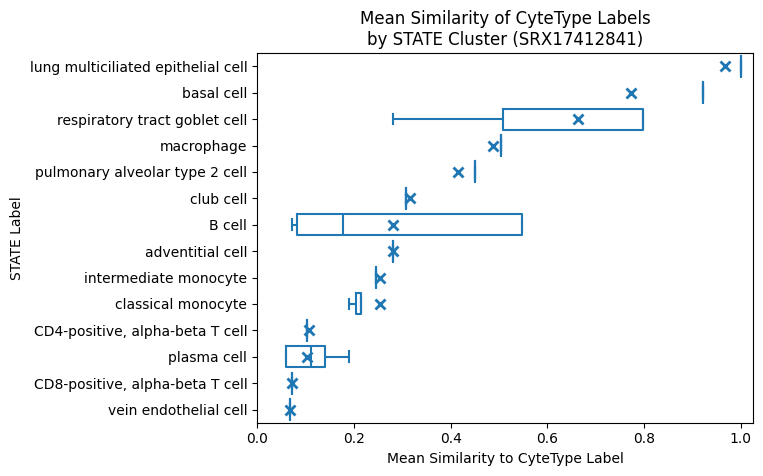

In [57]:
summaries = similarities.groupby("author_label").describe()
mean_similarities = summaries["cytescore_similarity"]["mean"].sort_values(ascending=False)

sns.boxplot(
    data=similarities,
    x="cytescore_similarity",
    y="author_label",
    order=mean_similarities.index,
    fill=False,
    fliersize=0
)

sns.pointplot(
    data=similarities,
    x="cytescore_similarity",
    y="author_label",
    order=mean_similarities.index,
    linestyle="none",
    errorbar=None,
    marker="x"
)

plt.ylabel("STATE Label")
plt.xlabel("Mean Similarity to CyteType Label")
plt.xlim([0, 1.025])
plt.title("Mean Similarity of CyteType Labels\nby STATE Cluster (SRX17412841)")

summaries["cytescore_similarity"].sort_values(by="mean", ascending=False)

## Distributions of similarity scores by cluster and algorithm

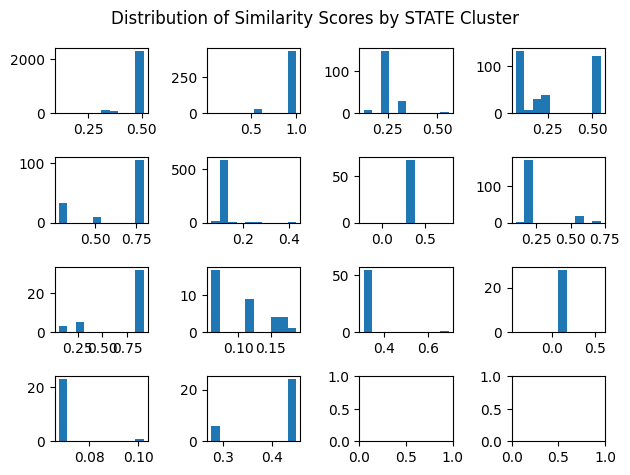

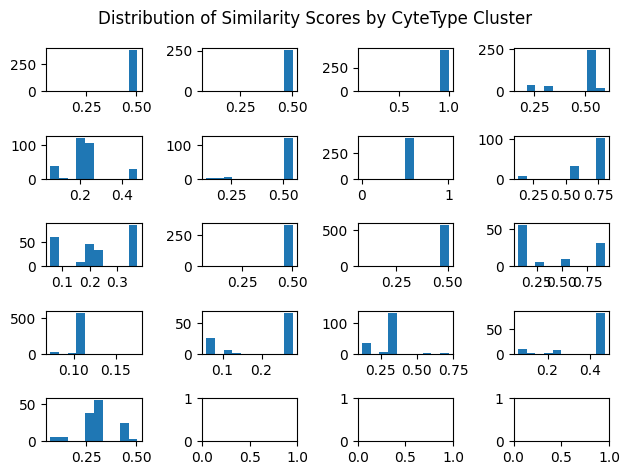

In [ ]:
cols = 4

fig_state, axs_state = plt.subplots(ncols=cols, nrows=math.ceil(similarities["author_label"].nunique() / cols))
fig_cyte, axs_cyte = plt.subplots(ncols=cols, nrows=math.ceil(similarities["algorithm_label"].nunique() / cols))

for i,label in enumerate(similarities["author_label"].unique()):
    axs_state[i // cols, i % cols].hist(similarities[similarities["author_label"] == label]["cytescore_similarity"])

for i,label in enumerate(similarities["algorithm_label"].unique()):
    axs_cyte[i // cols, i % cols].hist(similarities[similarities["algorithm_label"] == label]["cytescore_similarity"])

fig_state.suptitle("Distribution of Similarity Scores by STATE Cluster")
fig_cyte.suptitle("Distribution of Similarity Scores by CyteType Cluster")

fig_state.tight_layout()
fig_cyte.tight_layout()

## STATE label that best matches each CyteType cluster

In [68]:
# Cluster approach: one CyteType label per cluster (algorithm_label) and one STATE
# label per cluster = the author_label (STATE annotation) that is most abundant
# in cells assigned to that cluster.

_key = (
    ["algorithm", "algorithm_label"]
    if similarities["algorithm"].nunique() > 1
    else ["algorithm_label"]
)

def _dominant_state_and_stats(g: pd.DataFrame) -> pd.Series:
    vc = g["author_label"].value_counts()
    top = vc.index[0]
    n_top = int(vc.iloc[0])
    n = len(g)
    return pd.Series(
        {
            "stateLabel": top,
            "nCellsInCluster": n,
            "nDominantState": n_top,
            "fracDominantState": n_top / n if n else float("nan"),
        }
    )

_by_cluster = similarities.groupby(_key, group_keys=True).apply(
    _dominant_state_and_stats, include_groups=False
)
cluster_state_cytetype = _by_cluster.reset_index()
cluster_state_cytetype = cluster_state_cytetype.rename(
    columns={"algorithm_label": "cyteTypeLabel"}
)
sort_cols = [c for c in ("algorithm", "cyteTypeLabel") if c in cluster_state_cytetype.columns]
cluster_state_cytetype = cluster_state_cytetype.sort_values(sort_cols, kind="stable")

print("CyteType cluster -> STATE label (most abundant author_label in cluster):\n")
print(f"Number of CyteType clusters: {len(cluster_state_cytetype['cyteTypeLabel'].unique())}")
print(f"Number of STATE labels: {len(cluster_state_cytetype['stateLabel'].unique())}")
display(cluster_state_cytetype.sort_values(by="fracDominantState"))

CyteType cluster -> STATE label (most abundant author_label in cluster):

Number of CyteType clusters: 17
Number of STATE labels: 9


,cyteTypeLabel,stateLabel,nCellsInCluster,nDominantState,fracDominantState
1,Airway basal cell,basal cell,106,32,0.301887
0,Activated interstitial macrophage,macrophage,230,84,0.365217
15,Stromal-associated interstitial macrophage,classical monocyte,300,123,0.410000
2,Alveolar macrophage,club cell,132,55,0.416667
11,Matrix fibroblast,adventitial cell,100,67,0.670000
14,Recruited inflammatory macrophage,macrophage,336,242,0.720238
9,Club cell - metaplastic,respiratory tract goblet cell,144,104,0.722222
13,Non-classical monocyte,macrophage,182,134,0.736264
10,"Interstitial macrophage, complement-high",macrophage,103,83,0.805825
8,Ciliated epithelial cells,"CD4-positive, alpha-beta T cell",605,571,0.943802
